In [1]:
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    roc_curve,
    auc,
)
import nibabel as nib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from matplotlib import rcParams


from deap import base, creator, tools, algorithms  # evolutionary search
import matplotlib.pyplot as plt
import seaborn as sns 
from tqdm import tqdm

# Local/project modules 
from run_models import train, test
from models import * 
from ConvolutionalAE import ConvolutionalAE_upd
from utils import *



/home/jurgen/.local/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


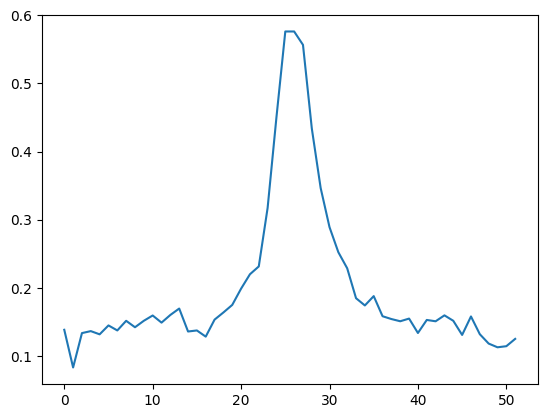

In [2]:
rat_data_postGAD = np.load('data/B0_corrected_ratTumorData_updated_postGd.npz')
Rat_Z_Spectras = 1- rat_data_postGAD['zspec']
Rat_Healthy_Idx = rat_data_postGAD['voxelInds_healthy']
Rat_Tumor_Idx = rat_data_postGAD['voxelInds_tumor']
rat_healthy_all = Rat_Z_Spectras[Rat_Healthy_Idx]
rat_tumor_all = Rat_Z_Spectras[Rat_Tumor_Idx]

plt.plot(rat_healthy_all[0])


In [3]:
rat_data_HEALTHY_TRAIN = np.load('data/ratData_healthy_all4_rats.npz')
Rat_Z_Spectras_HEALTHY_TRAIN = 1- rat_data_HEALTHY_TRAIN['zspec']
Rat_Healthy_Idx__HEALTHY_TRAIN = rat_data_HEALTHY_TRAIN['voxelInds_healthy']
rat_healthy_all_HEALTHY_TRAIN = Rat_Z_Spectras_HEALTHY_TRAIN[Rat_Healthy_Idx__HEALTHY_TRAIN]


In [4]:
N = rat_healthy_all.shape[1]           # 52
n_sparse = 26
sparse_idxs = np.linspace(0, N-1, n_sparse, dtype=int)
Rat_Healthy_Idx_sparse = Rat_Healthy_Idx
Rat_Tumor_Idx_sparse =Rat_Tumor_Idx
rat_healthy_all_sparse = rat_healthy_all[:, sparse_idxs]  # shape = (11483, 10)
rat_tumor_all_sparse = rat_tumor_all[:,sparse_idxs]
Rat_Z_Spectras_sparse = Rat_Z_Spectras[:,sparse_idxs]

Rat_Healthy_Idx__HEALTHY_TRAIN_sparse = Rat_Healthy_Idx__HEALTHY_TRAIN
rat_healthy_all_HEALTHY_TRAIN_sparse= rat_healthy_all_HEALTHY_TRAIN[:,sparse_idxs]
Rat_Z_Spectras_HEALTHY_TRAIN_sparse = Rat_Z_Spectras_HEALTHY_TRAIN[:,sparse_idxs]

(147456, 26)


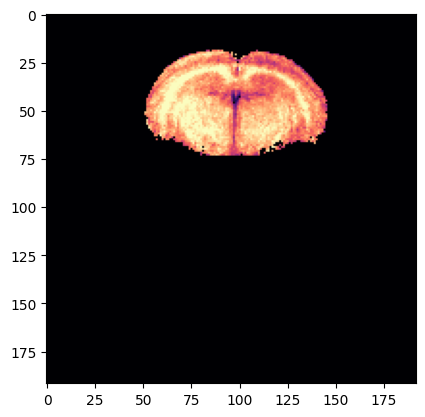

In [5]:
# --- Reconstruct Original Image ---
Healthy_Voxel_img_train = Rat_Z_Spectras_HEALTHY_TRAIN_sparse
inds = Rat_Healthy_Idx__HEALTHY_TRAIN_sparse
tempImg = np.zeros((4,192,192,26))  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all_HEALTHY_TRAIN_sparse     # Assign values at indexed positions
Healthy_Voxel_img_train = tempImg_flat.reshape((4,192,192,26))  # Reshape back
Healthy_Voxel_img_train.shape
Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 26)
print(Train_Image_Set.shape)
Train_Image_Set_indx = np.where(Train_Image_Set.sum(axis=1) >0)
train_extracted = Train_Image_Set[Train_Image_Set_indx]
train_extracted.shape

plt.imshow(Healthy_Voxel_img_train[3,:,:,0], vmin = 0, vmax=0.35, cmap='magma')



In [6]:
train_extracted.shape

(16548, 26)

In [7]:
print(Train_Image_Set.shape)

(147456, 26)


In [8]:
# --- Reconstruct Original Image ---
Tumor_Voxel_img =1- Rat_Z_Spectras_sparse
inds = Rat_Tumor_Idx
tempImg = np.zeros((4, 192, 192,26)) # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_tumor_all_sparse # Assign values at indexed positions
Tumor_Voxel_img = tempImg_flat.reshape((4, 192, 192,26))  # Reshape back
Tumor_Voxel_img.shape

(4, 192, 192, 26)

(4, 192, 192, 26)


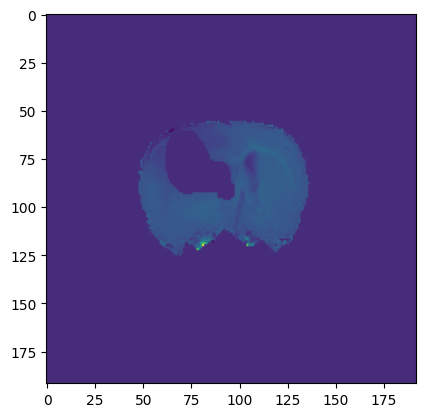

In [9]:
# --- Reconstruct Original Image ---
rat_image_shape = (4,192,192,26)
Healthy_Voxel_img_postGAD = Rat_Z_Spectras_sparse
inds = Rat_Healthy_Idx_sparse
tempImg = np.zeros(rat_image_shape)  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  rat_healthy_all_sparse   # Assign values at indexed positions
Healthy_Voxel_img_postGAD = tempImg_flat.reshape(rat_image_shape)  # Reshape back
print(Healthy_Voxel_img_postGAD.shape)
plt.imshow(Healthy_Voxel_img_postGAD[2,:,:,0])


In [10]:


Test_Image_Set = Tumor_Voxel_img.reshape(-1, 26)
print(Test_Image_Set.shape)
Test_Image_Set_indx = np.where(Test_Image_Set.sum(axis=1) > 0)[0]
Healthy_test = Healthy_Voxel_img_postGAD.reshape(-1, 26)
Healthy_test_idx = np.where(Healthy_test.sum(axis=1) > 0)[0]
test_idx =np.concatenate([Test_Image_Set_indx,Healthy_test_idx])
print(Test_Image_Set_indx.shape)




(147456, 26)
(1495,)


In [11]:


test_extracted= np.concatenate([Rat_Z_Spectras_sparse[Test_Image_Set_indx],Rat_Z_Spectras_sparse[Healthy_test_idx]], axis=0)
test_extracted.shape
Test_img =Rat_Z_Spectras_sparse
inds = test_idx
tempImg = np.zeros((4,192,192,26))  # Shape (3, 192, 192, 52)
tempImg_flat = tempImg.reshape(-1, 26)           # Flatten to (2352000, 52)
tempImg_flat[inds, :] =  test_extracted      # Assign values at indexed positions
Test_img = tempImg_flat.reshape((4,192,192,26))  # Reshape back
print(Test_img.shape)


(4, 192, 192, 26)


In [12]:

Healthy_Voxel_img_all   = Healthy_Voxel_img_train
Healthy_Voxel_img_train = Healthy_Voxel_img_all[:3]        
Healthy_Voxel_img_val   = Healthy_Voxel_img_all[-1]       

Train_Image_Set = Healthy_Voxel_img_train.reshape(-1, 8)
Val_Image_Set   = Healthy_Voxel_img_val.reshape(-1, 8)

train_extracted = Train_Image_Set
val_extracted   = Val_Image_Set
print("train_extracted:", train_extracted.shape)
print("val_extracted:  ", val_extracted.shape)


train_extracted: (359424, 8)
val_extracted:   (119808, 8)


In [13]:

rat_train_data   = train_extracted
rat_val_data     = val_extracted
rat_test_data    = test_extracted

rat_train_labels = np.ones(len(rat_train_data), dtype=int)   # all healthy
rat_val_labels   = np.ones(len(rat_val_data),   dtype=int)   # all healthy
rat_test_labels  = np.concatenate(
    [np.ones(len(Test_Image_Set_indx)), np.zeros(len(Healthy_test_idx))],
    axis=0
).astype(int)

print("Train data shape:", rat_train_data.shape)
print("Val   data shape:", rat_val_data.shape)
print("Test  data shape:", rat_test_data.shape)
print("Train label counts:", np.unique(rat_train_labels, return_counts=True))
print("Val   label counts:", np.unique(rat_val_labels,   return_counts=True))
print("Test  label counts:", np.unique(rat_test_labels,  return_counts=True))


Train data shape: (359424, 8)
Val   data shape: (119808, 8)
Test  data shape: (14250, 26)
Train label counts: (array([1]), array([359424]))
Val   label counts: (array([1]), array([119808]))
Test  label counts: (array([0, 1]), array([12755,  1495]))


In [14]:
X_train = torch.from_numpy(rat_train_data).float().unsqueeze(1)  # (N,1,52)
X_val   = torch.from_numpy(rat_val_data).float().unsqueeze(1)
X_test  = torch.from_numpy(rat_test_data).float().unsqueeze(1)


In [15]:

print("new shape: ", X_train.shape, X_val.shape, X_test.shape)

train_ds = TensorDataset(X_train)
val_ds   = TensorDataset(X_val)
test_ds  = TensorDataset(X_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)
y_train, y_val, y_test = rat_train_labels, rat_val_labels, rat_test_labels


new shape:  torch.Size([359424, 1, 8]) torch.Size([119808, 1, 8]) torch.Size([14250, 1, 26])


In [16]:

R, H, W, O = Tumor_Voxel_img.shape
print(f"Expected 8 offsets, got {O}")

VAL_RAT_ID = 2  
block = H * W
start = VAL_RAT_ID * block
end   = start + block


Expected 8 offsets, got 26


In [17]:

# Masks to select flat indices for the held-out rat
tumor_mask_val   = (Test_Image_Set_indx >= start) & (Test_Image_Set_indx < end)
healthy_mask_val = (Healthy_test_idx   >= start)  & (Healthy_test_idx   < end)


In [18]:

#HOLDOUT VS TEST SET 
tumor_idx_val    = Test_Image_Set_indx[tumor_mask_val]
healthy_idx_val  = Healthy_test_idx[healthy_mask_val]
tumor_idx_test   = Test_Image_Set_indx[~tumor_mask_val]
healthy_idx_test = Healthy_test_idx[~healthy_mask_val]


In [19]:

val_unhealthy_extracted = np.vstack([
    Rat_Z_Spectras_sparse[tumor_idx_val],
    Rat_Z_Spectras_sparse[healthy_idx_val]
]).astype(np.float32)  # (N_val_unhealthy, 26)

rat_test_extracted = np.vstack([
    Rat_Z_Spectras_sparse[tumor_idx_test],
    Rat_Z_Spectras_sparse[healthy_idx_test]
]).astype(np.float32)  # (N_test, 26)

# Labels: tumor=1, healthy=0
y_val_unhealthy = np.concatenate([
    np.ones(len(tumor_idx_val),    dtype=int),
    np.zeros(len(healthy_idx_val), dtype=int)
])
y_test = np.concatenate([
    np.ones(len(tumor_idx_test),    dtype=int),
    np.zeros(len(healthy_idx_test), dtype=int)
])


In [20]:


rat_test_data   = rat_test_extracted
rat_test_labels = y_test
X_test          = torch.from_numpy(rat_test_data).float().unsqueeze(1)           # (N,1,26)
test_loader     = DataLoader(TensorDataset(X_test), batch_size=128, shuffle=False)

X_val_unhealthy     = torch.from_numpy(val_unhealthy_extracted).float().unsqueeze(1)  # (M,1,26)
val_unhealthy_loader= DataLoader(TensorDataset(X_val_unhealthy), batch_size=128, shuffle=False)


In [21]:

print("Held-out Unhealthy VAL (26):", val_unhealthy_extracted.shape, y_val_unhealthy.shape)
print("Two-rat TEST (26):          ", rat_test_extracted.shape,      y_test.shape)


Held-out Unhealthy VAL (26): (4930, 26) (4930,)
Two-rat TEST (26):           (9320, 26) (9320,)


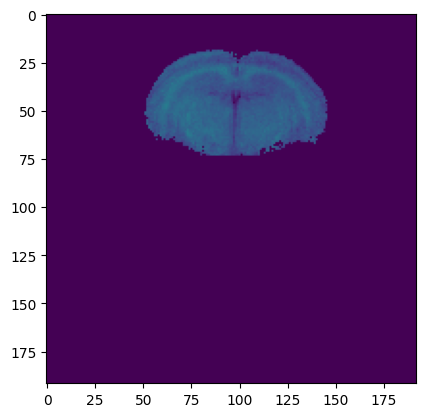

In [22]:
plt.imshow(Healthy_Voxel_img_val[:,:,0], vmin = 0, vmax =1, )

## Load Model

In [23]:
cae_model = ConvolutionalAE_upd(seq_len=26)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

checkpoint_cae = "Checkpoints/26_Off_B0Corrected_best_model.pth"

state_dict = torch.load(checkpoint_cae, map_location=torch.device('cpu'))
cae_model.load_state_dict(state_dict)
cae_model.to(device)


ConvolutionalAE_upd(
  (conv_down1): Sequential(
    (0): Conv1d(1, 8, kernel_size=(3,), stride=(1,), padding=same)
    (1): GELU(approximate='none')
    (2): Conv1d(8, 16, kernel_size=(3,), stride=(1,), padding=same)
    (3): GELU(approximate='none')
  )
  (max_pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_down2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=same)
    (1): GELU(approximate='none')
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=same)
    (3): GELU(approximate='none')
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fnn_down): Sequential(
    (0): Linear(in_features=416, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=16, bias=True)
    (3): ReLU()
  )
  (fnn_up): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=416, bias=True)
    (3): ReLU()
    (4): Un

In [24]:
cae_test_results = test(cae_model,test_loader)
cae_val_unhealthy_rec = test(cae_model, val_unhealthy_loader)

# ###################################################################################################################################################

### Generate ROC

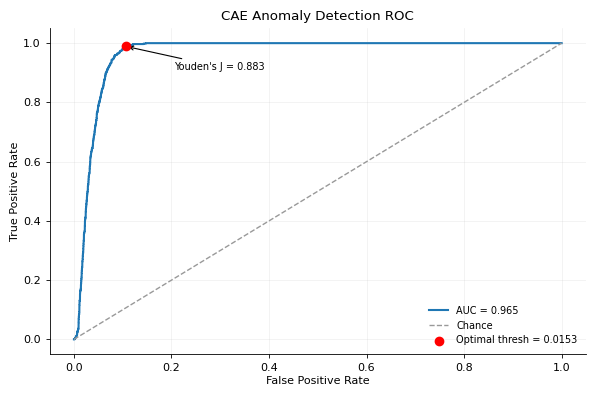

In [25]:
recon = X_test.squeeze(1)  # torch tensor, shape (N, features)
recon_errors = reconstruction_error(recon.cpu().numpy(), cae_test_results)  # (N,)
y_true = rat_test_labels  # binary array
metrics = roc_analysis(y_true, recon_errors, pos_label=1)
fig, ax = plot_roc_clean(metrics, save_path="figure_roc_cae.pdf")

In [26]:
print("=== ROC Summary ===")
print(summary_text(metrics))

=== ROC Summary ===
AUC: 0.965
Optimal threshold (Youden's J): 0.0153
Sensitivity: 0.989
Specificity: 0.894
Fraction flagged as anomaly: 16.8%
Threshold percentile: 83.3th



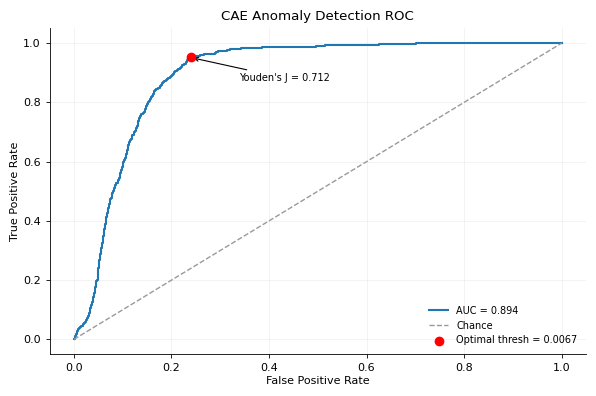

In [27]:
## VALIDATION ROC
recon = X_val_unhealthy.squeeze(1)
recon_errors_val = reconstruction_error(recon.cpu().numpy(), cae_val_unhealthy_rec)  # (N,)
y_true_val = y_val_unhealthy  # binary array
metrics = roc_analysis(y_true_val, recon_errors_val, pos_label=1)
fig, ax = plot_roc_clean(metrics, save_path="figure_roc_cae.pdf")

In [28]:
print("=== ROC Summary ===")
print(summary_text(metrics))

=== ROC Summary ===
AUC: 0.894
Optimal threshold (Youden's J): 0.0067
Sensitivity: 0.952
Specificity: 0.761
Fraction flagged as anomaly: 36.2%
Threshold percentile: 63.9th



In [29]:

healthy_inds = np.where(y_true_val == 0)[0]
thrshold_percentage =0.90
threshold_unsupervised = np.quantile(recon_errors_val[healthy_inds], thrshold_percentage)  # 99th percentile
print(f"Unsupervised  = {threshold_unsupervised:.5f}")


Unsupervised  = 0.02348


In [30]:

anomaly_score_val = recon_errors_val
norm_anom_score_cae = (anomaly_score_val - np.min(anomaly_score_val)) / (np.max(anomaly_score_val) - np.min(anomaly_score_val))
binary_score_val = (anomaly_score_val >=  threshold_unsupervised).astype(int)


In [31]:

anomaly_score_val = recon_errors_val.astype(float)
rng = anomaly_score_val.max() - anomaly_score_val.min()
norm_anom_score_val = (anomaly_score_val - anomaly_score_val.min()) / (rng if rng > 0 else 1.0)
binary_score_val = (anomaly_score_val >= float(threshold_unsupervised)).astype(np.uint8)

# 2) Flat index order must match how X_val_unhealthy was stacked: [tumor; healthy]
idx_order_val = np.concatenate([tumor_idx_val, healthy_idx_val])
assert idx_order_val.size == anomaly_score_val.shape[0], \
    f"VAL scores len {anomaly_score_val.shape[0]} != idx count {idx_order_val.size}"

# 3) Choose offsets dimension (26 if you built a sparse set, else 52)
if 'Rat_Z_Spectras_sparse' in globals():
    Rv, Hv, Wv, Ov = map(int, (3,192,192,26))   # e.g., (3,192,192,26)
else:
    Rv, Hv, Wv, Ov = map(int, rat_data_postGAD['imageShape']) # e.g., (3,192,192,52)

# 4) Scatter scores to flat canvas then reshape
Nvox_val = Rv * Hv * Wv
flat_norm_val = np.zeros((Nvox_val, Ov), dtype=np.float32)
flat_bin_val  = np.zeros((Nvox_val, Ov), dtype=np.uint8)

flat_norm_val[idx_order_val] = np.repeat(norm_anom_score_val[:, None], Ov, axis=1)
flat_bin_val[idx_order_val]  = np.repeat(binary_score_val[:,    None], Ov, axis=1)

anom_norm_img_val = flat_norm_val.reshape(Rv, Hv, Wv, Ov)
bin_img_val       = flat_bin_val.reshape(Rv, Hv, Wv, Ov)

# 5) Zero out non-validation rats (keep ONLY VAL_RAT_ID populated)
for ri in range(Rv):
    if ri != VAL_RAT_ID:
        anom_norm_img_val[ri] = 0.0
        bin_img_val[ri]       = 0

print("anom_norm_img_val:", anom_norm_img_val.shape,
      "| nonzero@offset0:", int((anom_norm_img_val[...,0] > 0).sum()))
print("bin_img_val:", bin_img_val.shape,
      "| positives@offset0:", int(bin_img_val[...,0].sum()))


anom_norm_img_val: (3, 192, 192, 26) | nonzero@offset0: 4929
bin_img_val: (3, 192, 192, 26) | positives@offset0: 910


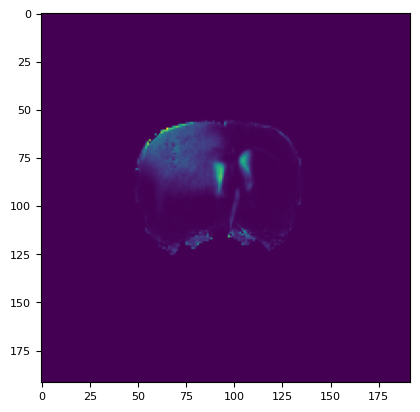

In [32]:
plt.imshow(anom_norm_img_val[2,:,:,0])


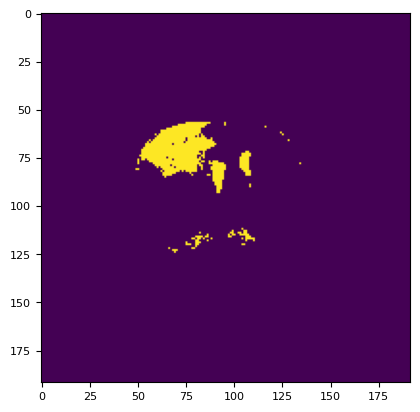

In [33]:
plt.imshow(bin_img_val[2,:,:,0])


In [34]:
# # Quick overlay vs GT for the validation rat + Dice score
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import to_rgb

# ri, oi = 2, 0  # rat index, offset index

# # Masks
# pred = bin_img_val[ri, :, :, oi].astype(bool)
# gt   = (Tumor_Voxel_img[ri, :, :, oi] > 0)  # GT: nonzero → True

# # Dice
# inter = np.logical_and(pred, gt).sum()
# p_sum = pred.sum()
# g_sum = gt.sum()
# dice = (2 * inter) / (p_sum + g_sum) if (p_sum + g_sum) else 0.0

# # Overlay (auto=red, GT=teal, overlap=yellow)
# H, W = pred.shape
# canvas = np.zeros((H, W, 4), dtype=float)
# rgba_auto    = (*to_rgb("#FF6B6B"), 0.85)
# rgba_truth   = (*to_rgb("#4ECDC4"), 0.85)
# rgba_overlap = (*to_rgb("#FFE66D"), 0.90)

# canvas[pred & ~gt] = rgba_auto
# canvas[gt & ~pred] = rgba_truth
# canvas[pred & gt]  = rgba_overlap

# fig, ax = plt.subplots(figsize=(4, 4), facecolor="black")
# ax.set_facecolor("black")
# ax.imshow(canvas, interpolation="nearest")
# ax.axis("off")
# ax.set_title(f"VAL rat {ri} — Dice={dice:.3f}", color="white")
# plt.show()

# print(f"Dice (rat {ri}, offset {oi}): {dice:.4f} | TP={inter}, P={p_sum}, T={g_sum}")


In [35]:

anomaly_score_cae = recon_errors
norm_anom_score_cae = (anomaly_score_cae - np.min(anomaly_score_cae)) / (np.max(anomaly_score_cae) - np.min(anomaly_score_cae))
binary_score_cae = (anomaly_score_cae >=  threshold_unsupervised).astype(int)


In [36]:

recon_errors_test = recon_errors
Nvox = R * H * W
anom_flat = np.zeros(Nvox, dtype=float)

split_t = len(tumor_idx_test)
anom_flat[tumor_idx_test]   = recon_errors_test[:split_t]
anom_flat[healthy_idx_test] = recon_errors_test[split_t:]
anom_img_3d  = anom_flat.reshape(R, H, W)
anom_img_cae = np.repeat(anom_img_3d[..., None], O, axis=-1)

print("anom_img_cae:", anom_img_cae.shape, " | nonzero voxels:", np.count_nonzero(anom_img_3d))


anom_img_cae: (4, 192, 192, 26)  | nonzero voxels: 9320


(-0.5, 191.5, 191.5, -0.5)

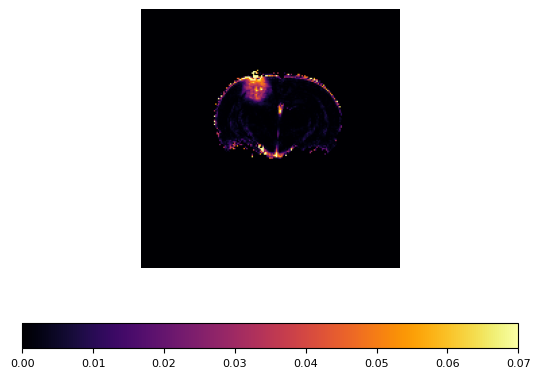

In [37]:
plt.imshow(anom_img_cae[0,:,:,0], cmap = "inferno",vmin= 0, vmax = 0.07)
plt.colorbar(orientation= "horizontal")
plt.axis("off")

In [38]:
# ============================================================================
# Verify we have predictions for all test voxels
# ============================================================================

idx_order = np.concatenate([tumor_idx_test, healthy_idx_test])


In [39]:

assert anomaly_score_cae.shape[0] == idx_order.shape[0], \
    f"Scores length {anomaly_score_cae.shape[0]} != num test voxels {idx_order.shape[0]}"


In [40]:

# Total voxels across all rats
Nvox = R * H * W

# Initialize flat arrays: (total_voxels, num_offsets)
flat_norm = np.zeros((Nvox, O), dtype=np.float32)  # normalized anomaly scores
flat_bin  = np.zeros((Nvox, O), dtype=np.uint8)    # binary anomaly mask

norm_2d = np.repeat(norm_anom_score_cae[:, None], O, axis=1).astype(np.float32)
bin_2d  = np.repeat(binary_score_cae[:, None], O, axis=1).astype(np.uint8)



# Place test voxel predictions into the full volume grid
flat_norm[idx_order] = norm_2d
flat_bin[idx_order]  = bin_2d

# Reshape from flat arrays into 4D brain volumes
anom_norm_img_cae = flat_norm.reshape(R, H, W, O)  # continuous anomaly scores [0, 1]
bin_img_cae       = flat_bin.reshape(R, H, W, O)   # binary anomaly predictions {0, 1}

# ============================================================================
# Zero out the validation rat (exclude from test set visualization)
# ============================================================================

anom_norm_img_cae[VAL_RAT_ID] = 0.0
bin_img_cae[VAL_RAT_ID]       = 0

# ============================================================================
# Summary statistics
# ============================================================================

print("anom_norm_img_cae:", anom_norm_img_cae.shape,
      "| nonzero @ offset0:", int((anom_norm_img_cae[..., 0] > 0).sum()))
print("bin_img_cae:", bin_img_cae.shape,
      "| positives @ offset0:", int(bin_img_cae[..., 0].sum()))

anom_norm_img_cae: (4, 192, 192, 26) | nonzero @ offset0: 9319
bin_img_cae: (4, 192, 192, 26) | positives @ offset0: 1242


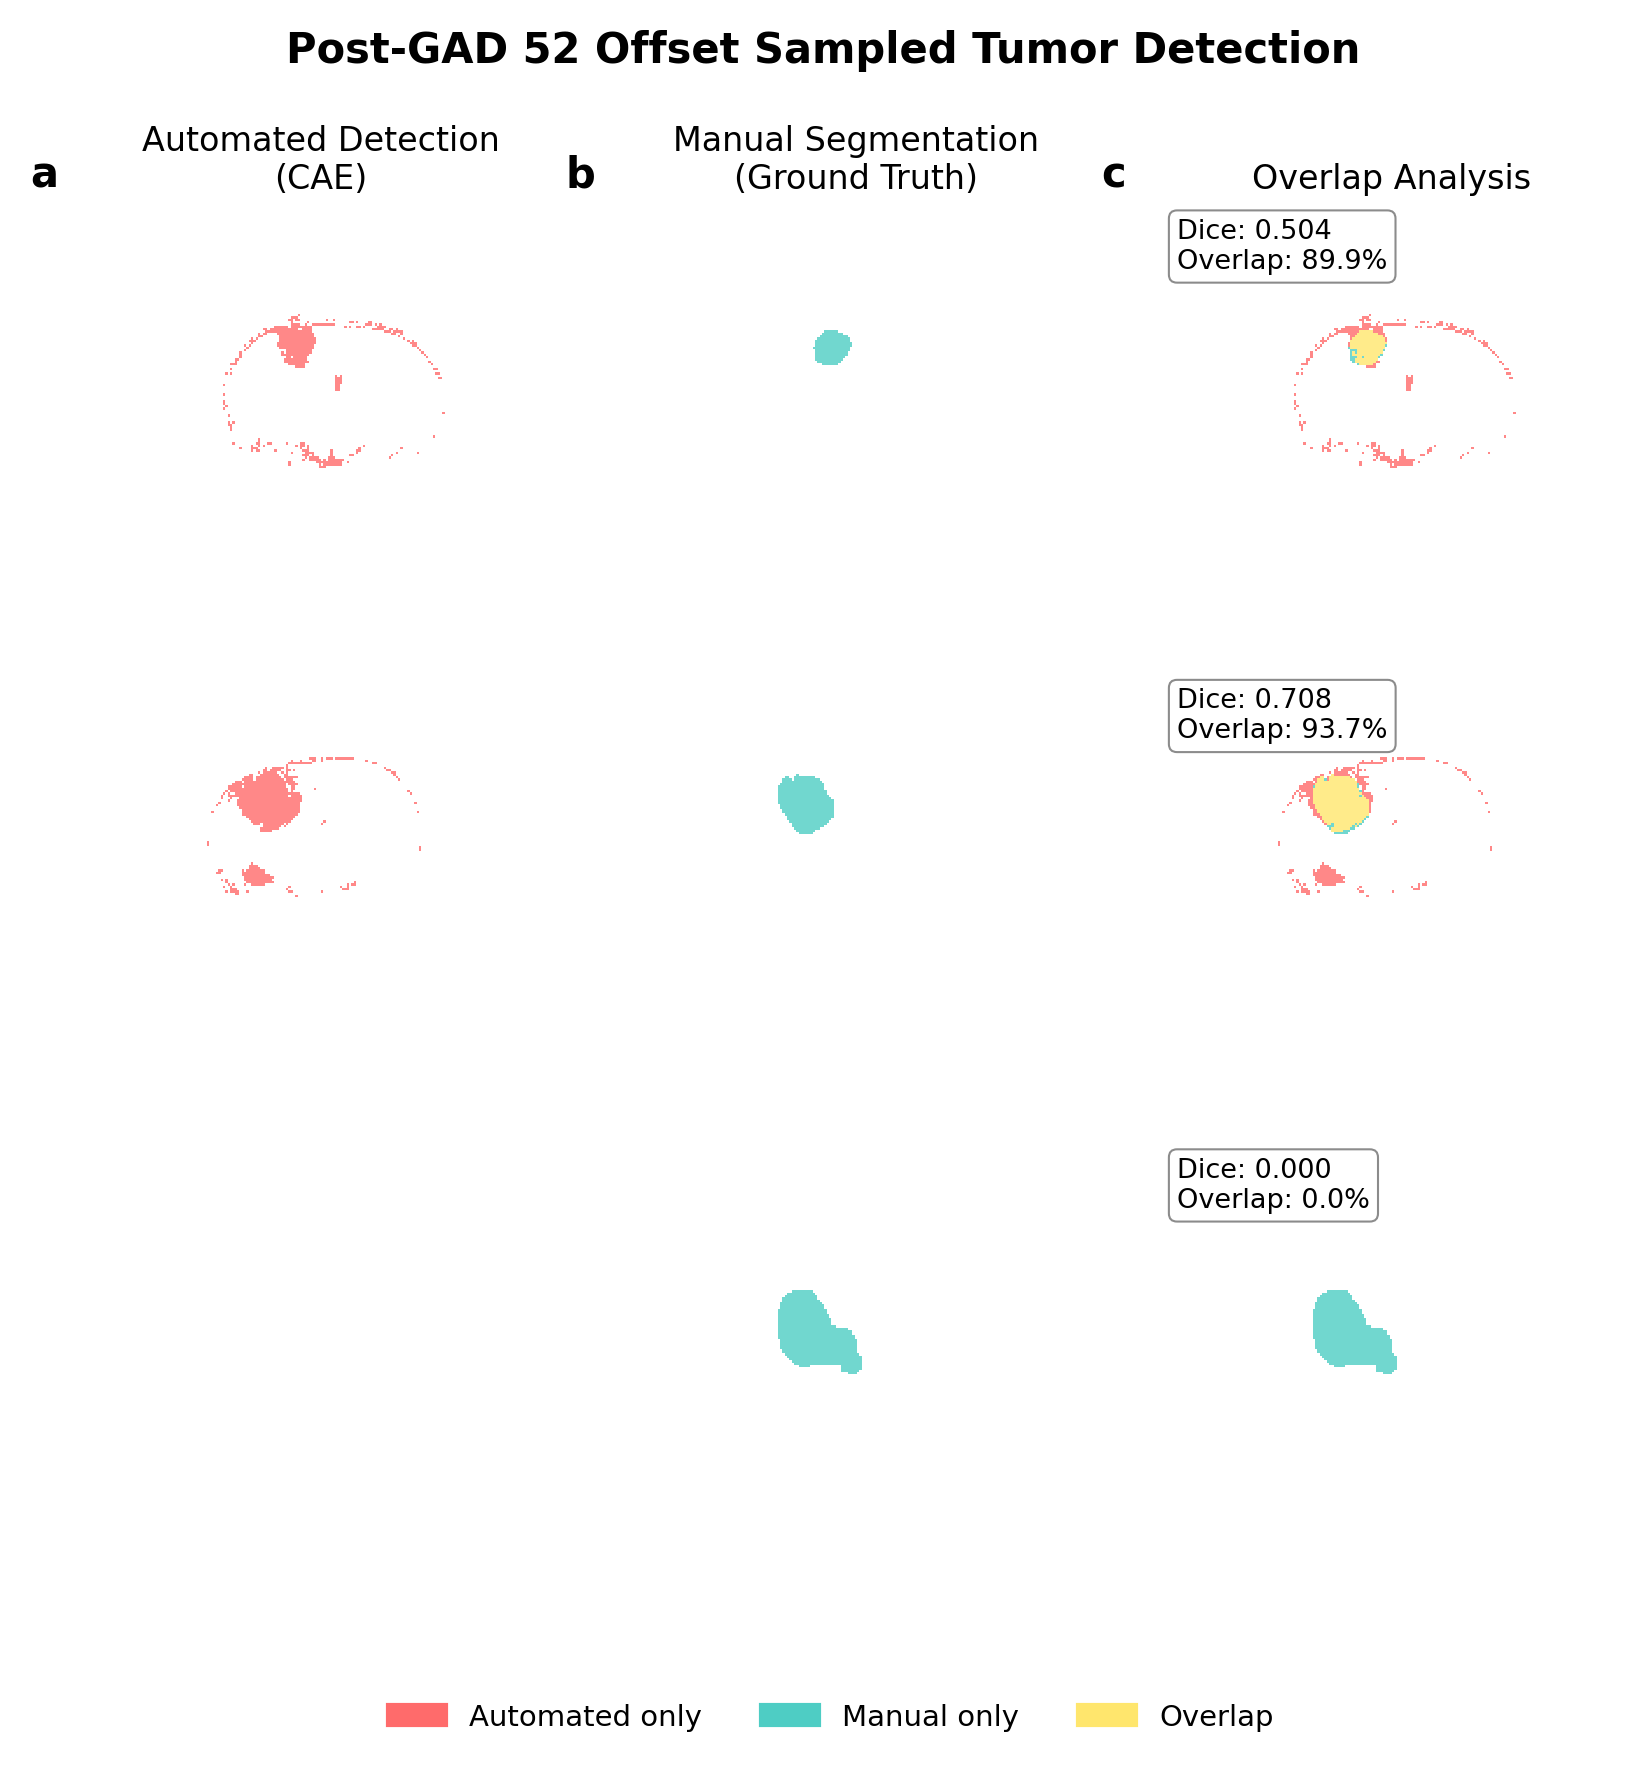

In [41]:
fig, axes = plot_tumor_detection(bin_img_cae, Tumor_Voxel_img, save_path="tumor_detection.png")

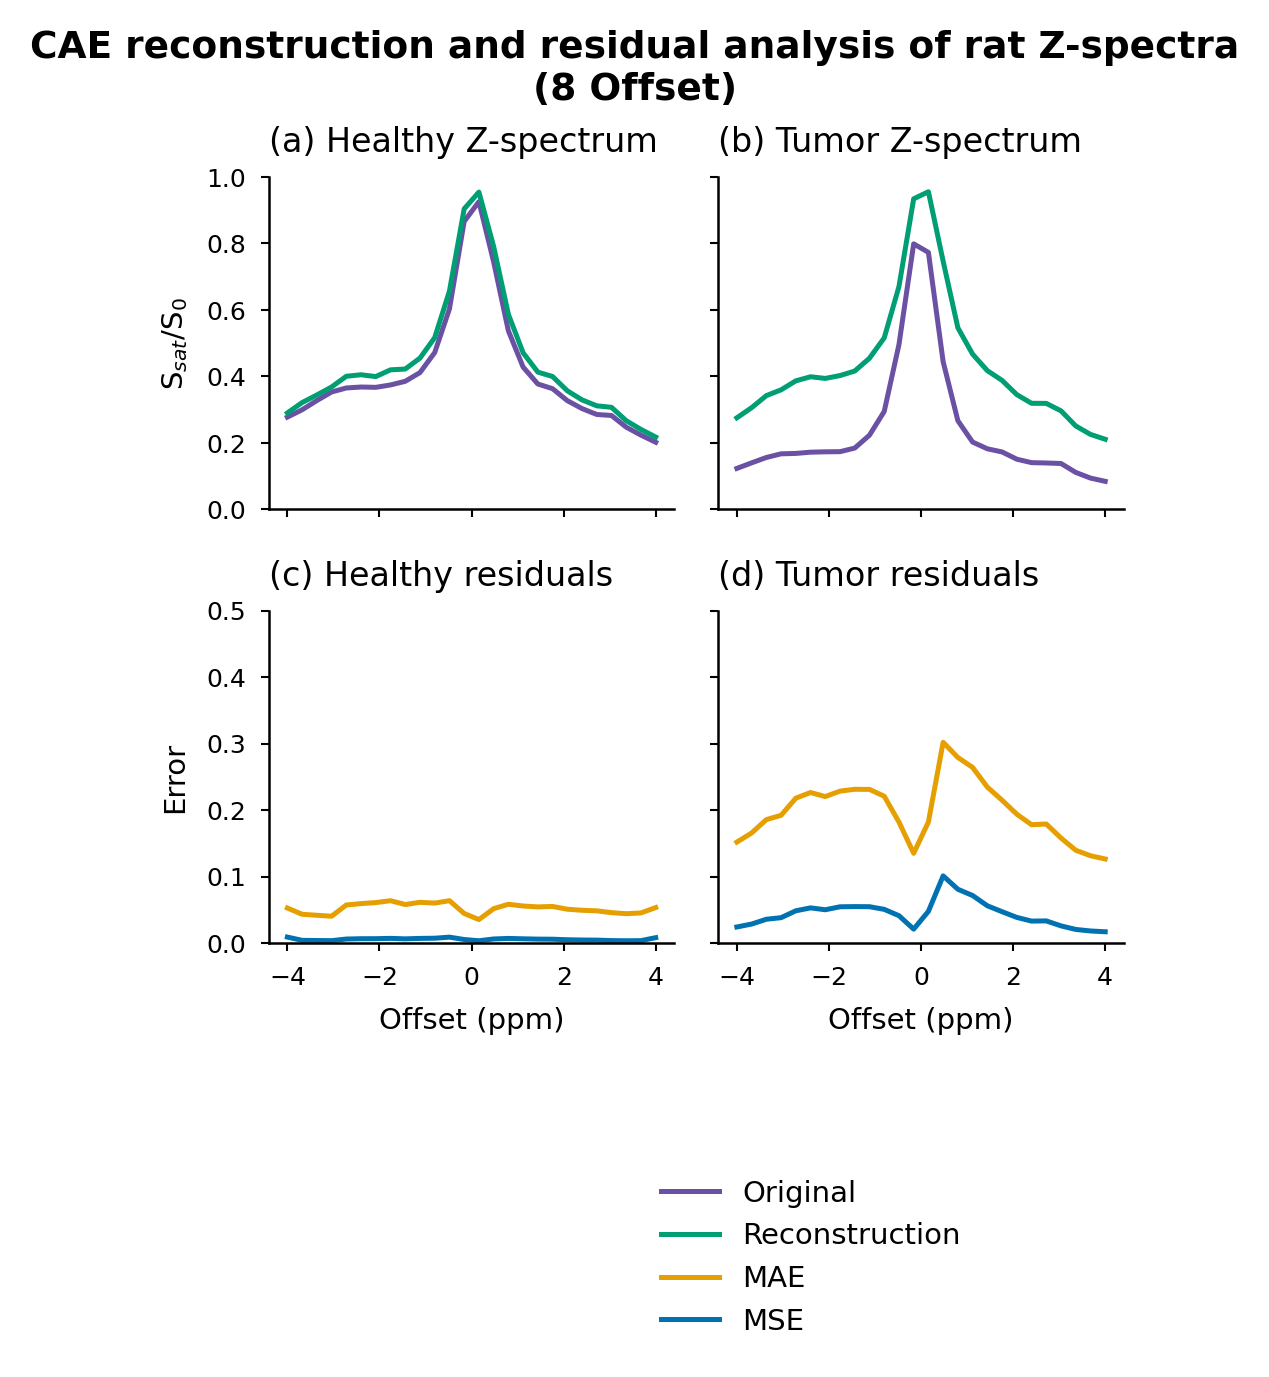

In [42]:
offset_axis = np.linspace(-4, 4, 26)
fig, axes = plot_zspec_recon_and_residuals(
    orig=X_test,                # (N,1,52) or (N,52) or torch.Tensor
    rec=cae_test_results,       # (N,52)
    y_true=rat_test_labels,     # (N,)
    offset_axis=offset_axis,
    save_path=None,             # e.g., "zspec_summary.pdf"
    show=True
)



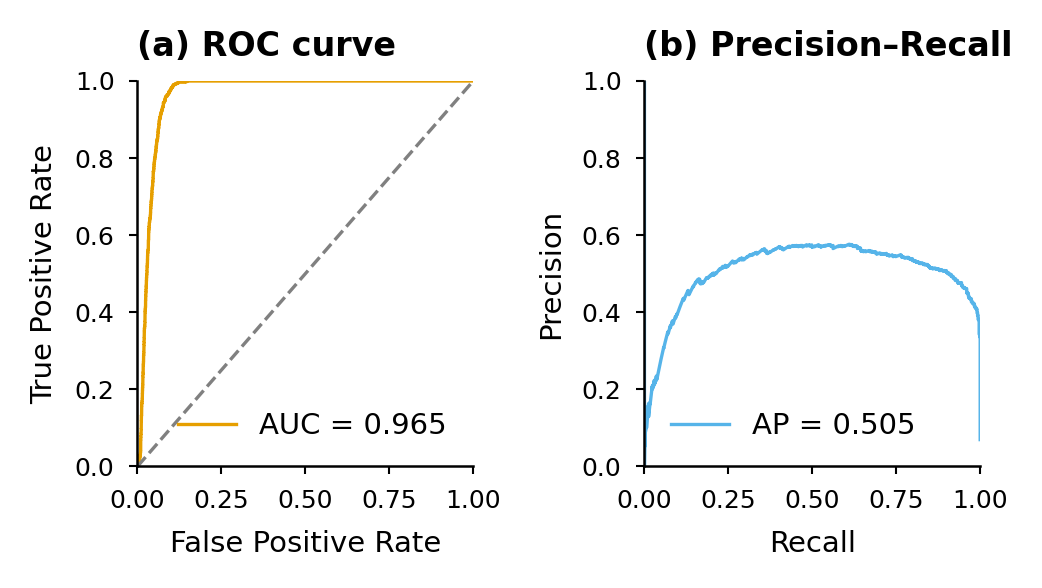

In [43]:
fig, axes = plot_roc_pr(y_true=rat_test_labels, scores=recon_errors,
                        pos_label=1, save_path=None, show=True)


In [44]:
nifti_image = nib.load('CDF1T1.nii')
cdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('SDF1T1.nii')
sdf1_T1 = nifti_image.get_fdata()
nifti_image = nib.load('SDF4T1.nii')
sdf4_T1 = nifti_image.get_fdata()
#
cdf1_T1 = np.rot90(cdf1_T1[:, :, 5],k = 3)

sdf4_T1 = np.rot90(sdf4_T1[:, :, 4],k = 3)

sdf1_T1 = np.rot90(sdf1_T1[:, :, 6],k = 3)

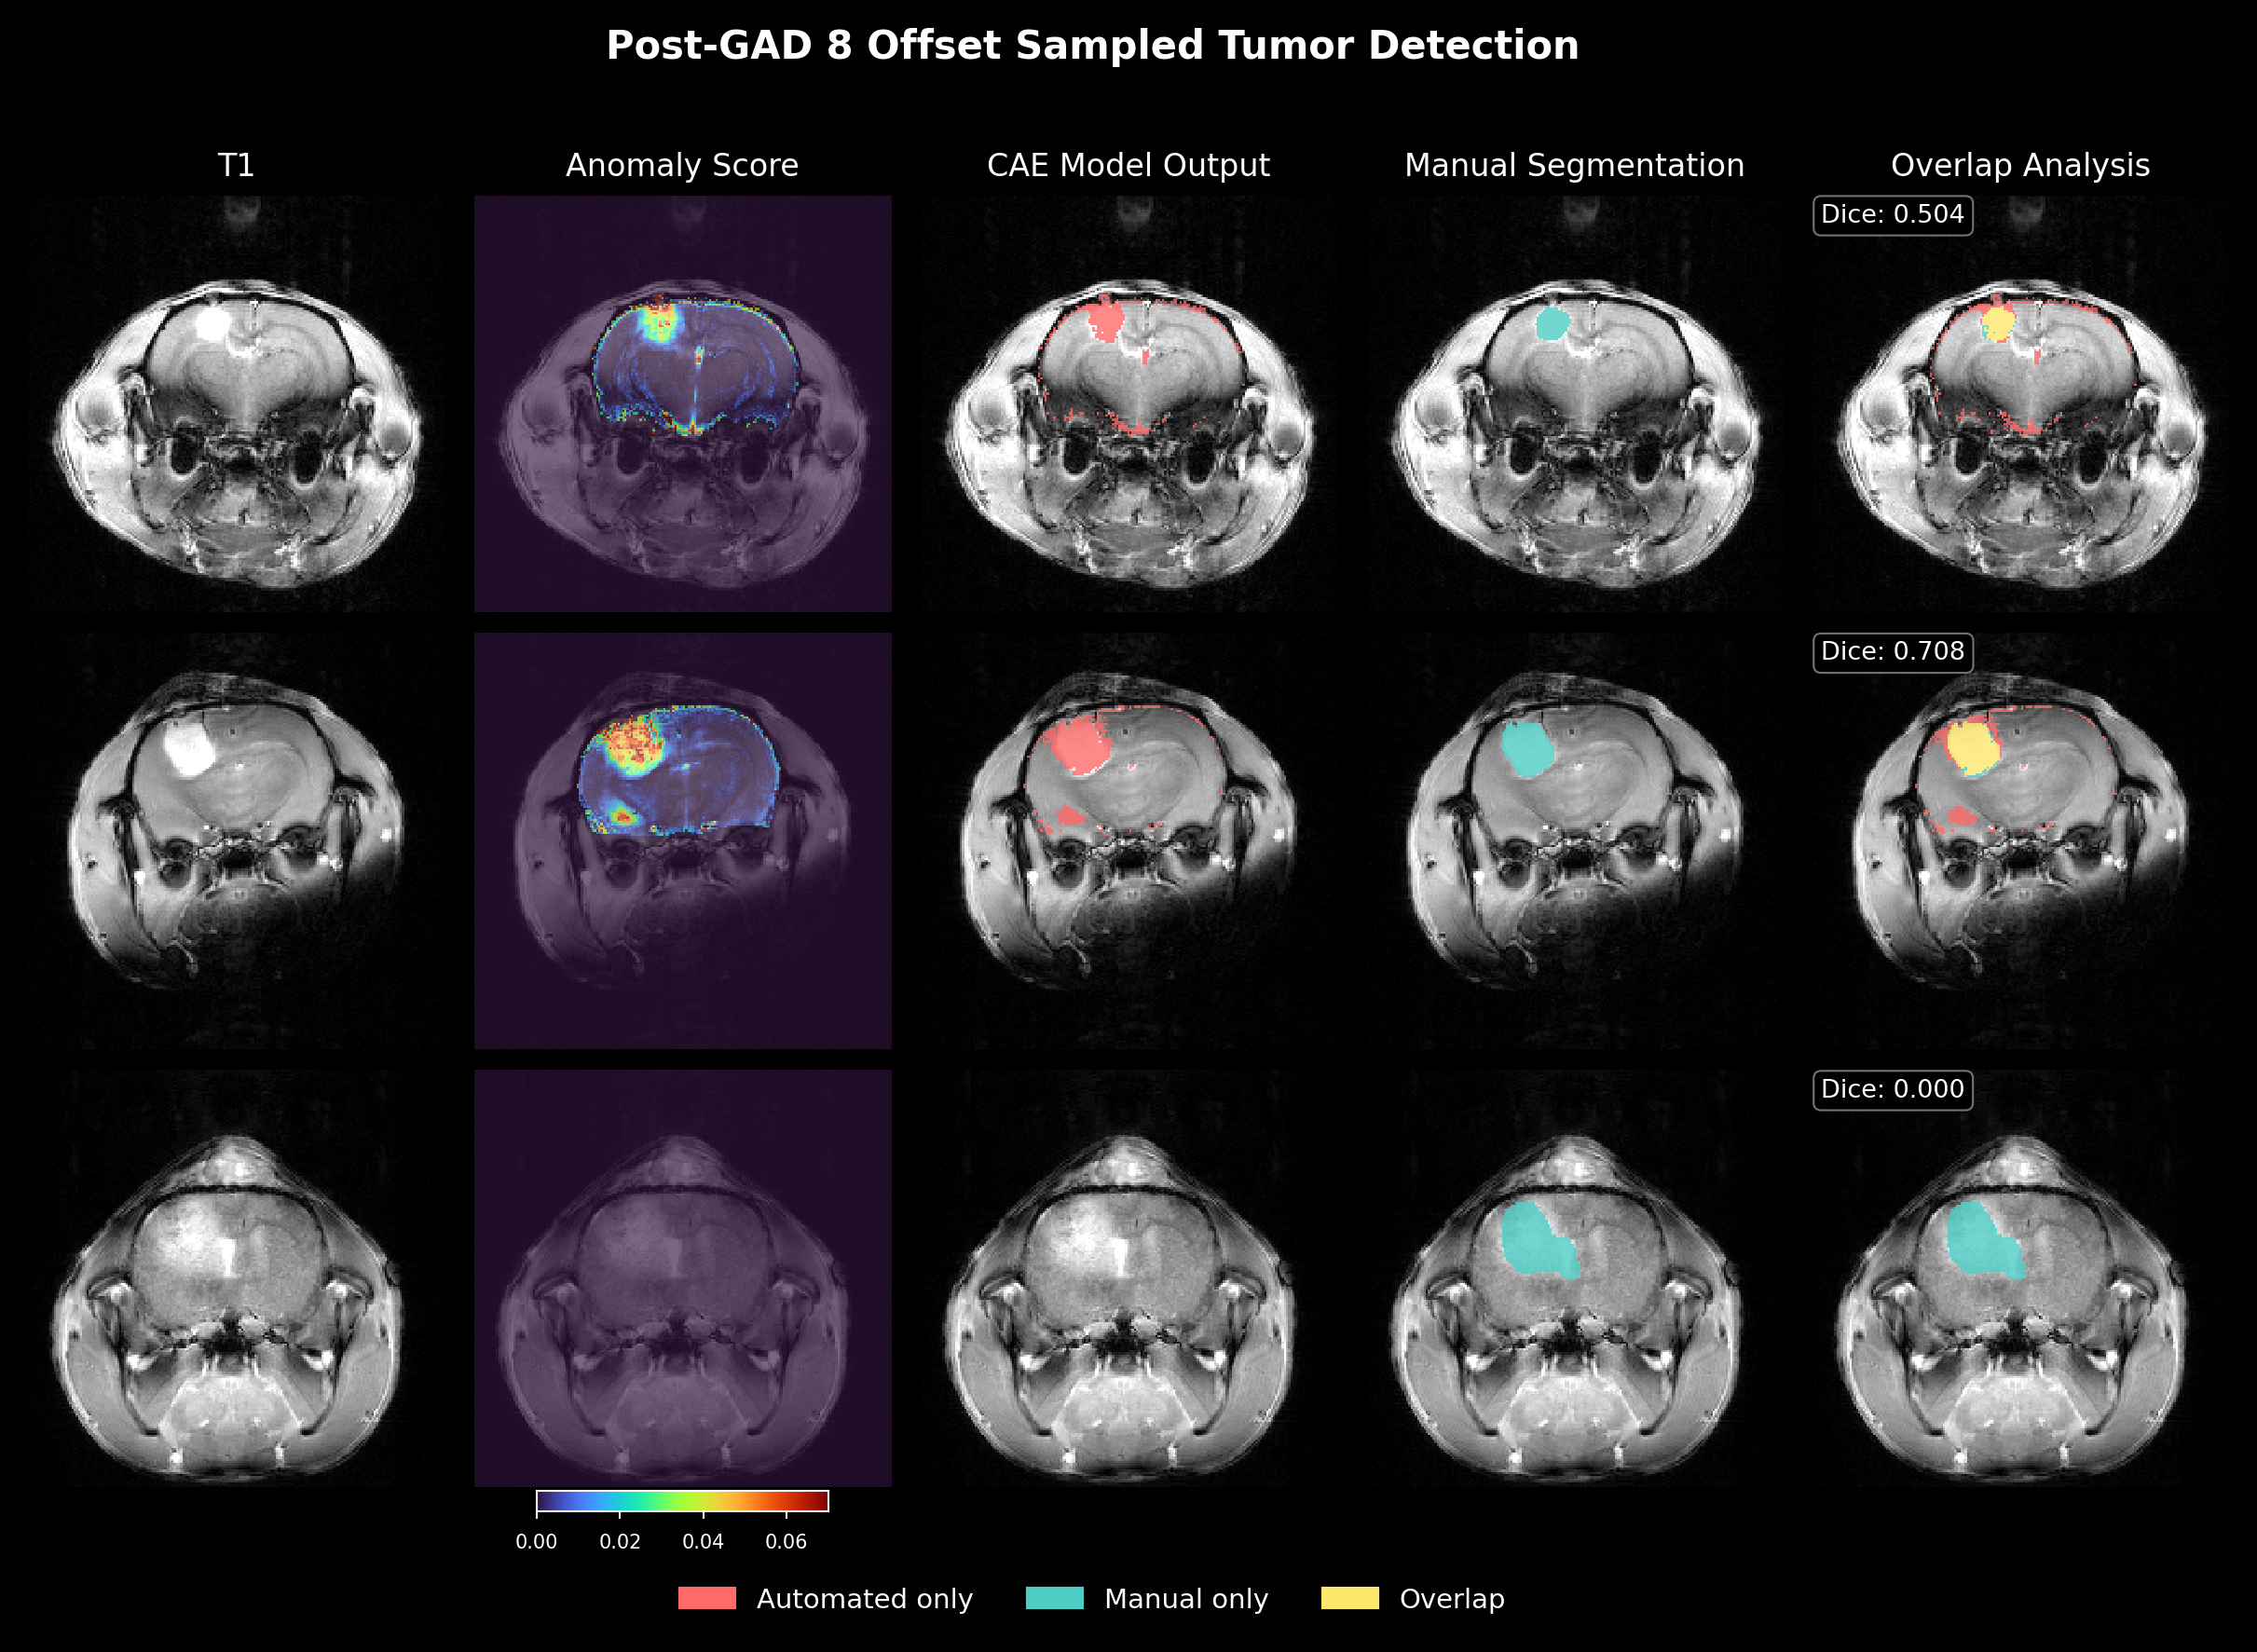

(<Figure size 3060x1800 with 16 Axes>,
 array([[<Axes: title={'center': 'T1'}>,
         <Axes: title={'center': 'Anomaly Score'}>,
         <Axes: title={'center': 'CAE Model Output'}>,
         <Axes: title={'center': 'Manual Segmentation'}>,
         <Axes: title={'center': 'Overlap Analysis'}>],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [45]:
plt.style.use('dark_background')  
t1_slices = (sdf4_T1, cdf1_T1, sdf1_T1)
auto2d  = bin_img_cae[..., 0].astype(bool)      # (3,H,W)
truth2d = Tumor_Voxel_img[..., 0].astype(bool)  # (3,H,W)

anom_3xHW = np.stack([
    anom_img_cae[0, ..., 0],
    anom_img_cae[1, ..., 0],
    anom_img_cae[2, ..., 0],
], axis=0)

plot_masks_over_t1_slices(
    t1_slices,
    auto2d,
    truth2d,
    anom_maps=anom_3xHW,
    anom_cmap='turbo',
    anom_alpha=0.65,
    save_path="tumor_detection_with_blankT1.png"
)


In [46]:

def load_rotate_transpose(path):
    vols     = np.load(path)["data"]          # (5, 192, 192)
    vols_rot = np.rot90(vols, k=-1, axes=(1,2))
    arr      = np.transpose(vols_rot, (1,2,0))  # (192, 192, 5)
    return arr
SDF1 = load_rotate_transpose('data/sdf1.npz')
print("SDF1 shape:", SDF1.shape)
SDF4 = load_rotate_transpose('data/sdf4.npz')
print("SDF4 shape:", SDF4.shape)
CDF1 = load_rotate_transpose('data/cdf1.npz')
print("CDF1 shape:", CDF1.shape)
CDF3 = load_rotate_transpose('data/cdf3.npz')
CDF3 = CDF3.transpose(1,2,0)
print("CDF3 shape:", CDF3.shape)

SDF1 shape: (192, 192, 5)
SDF4 shape: (192, 192, 5)
CDF1 shape: (192, 192, 5)
CDF3 shape: (192, 192, 5)


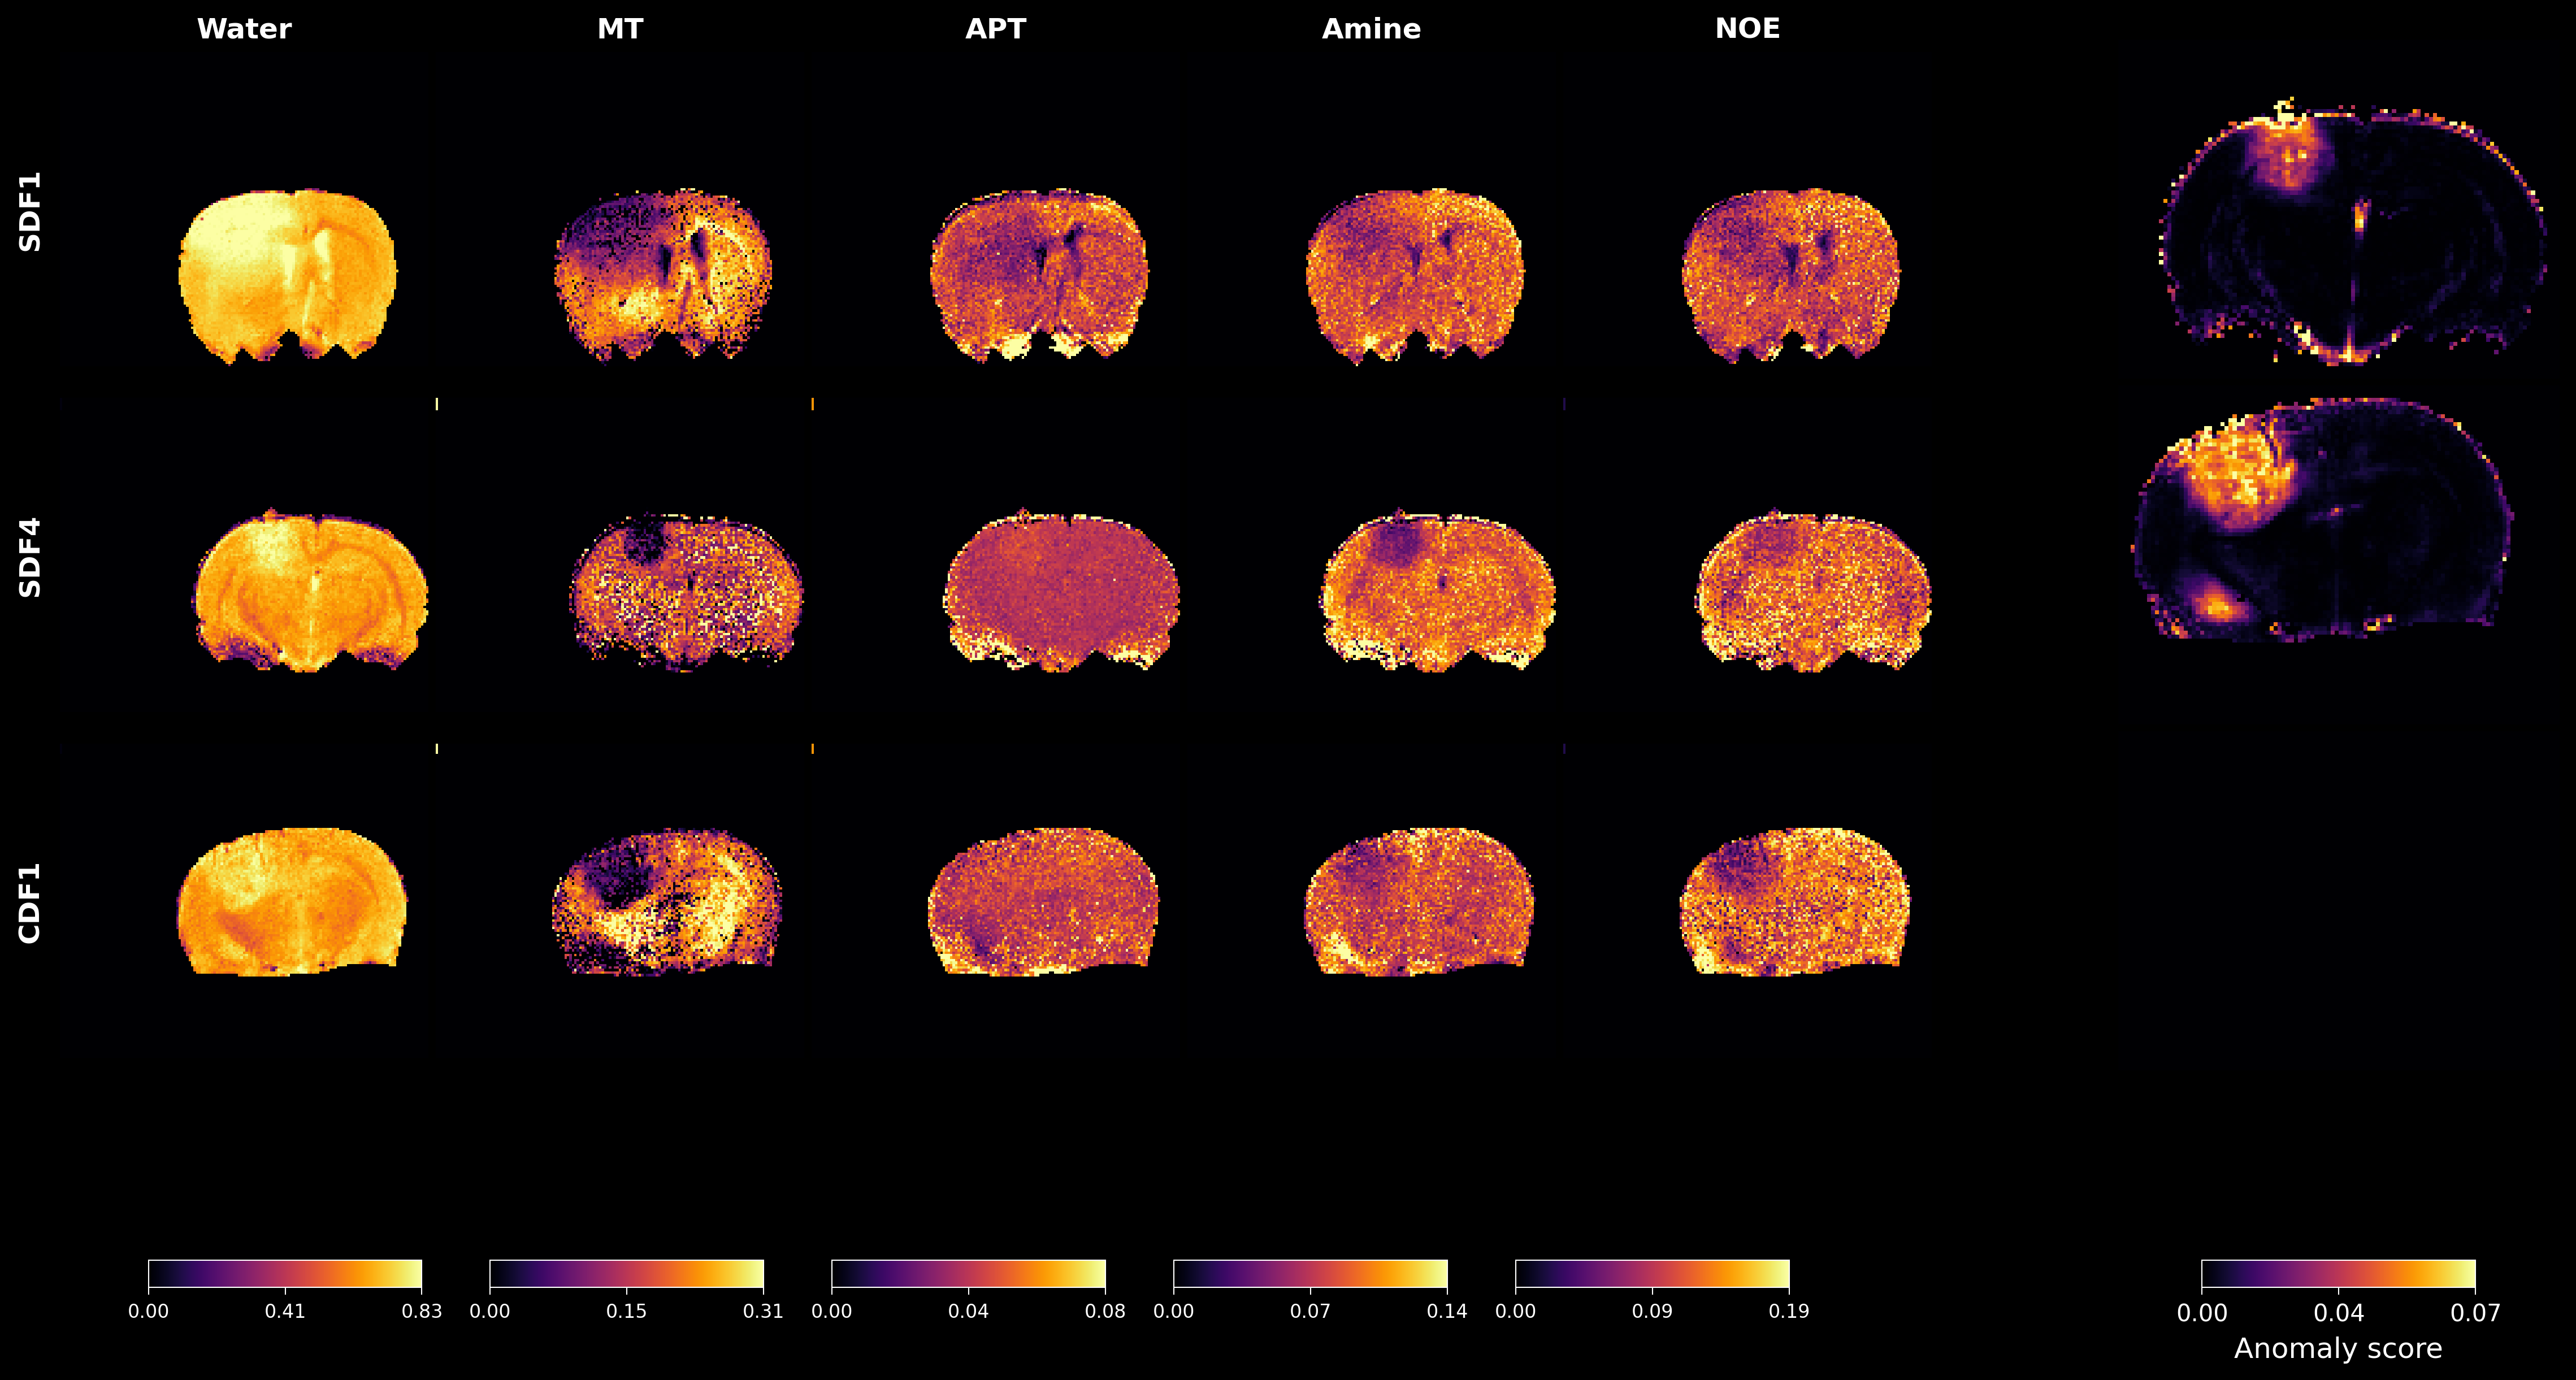

In [47]:
fig = plot_combined_grid_and_anomaly(SDF1, SDF4, CDF1, anom_img_cae)
plt.show()
